# Heart Rate Stress Level Prediction — Model Training

This notebook loads the preprocessed HRV features from `hrv_features.csv`,
trains a binary stress classifier, and outputs a **continuous stress level (0–100%)**
via `predict_proba`.

**Features:**
- 19 HRV features (time-domain, frequency-domain, nonlinear) — from camera+flash PPG
- 4 demographic features (age, gender_male, height_cm, weight_kg) — **optional**, imputed when missing

**Evaluation strategy:**
- Leave-One-Subject-Out (LOSO) cross-validation for unbiased, subject-independent evaluation
- Stratified k-fold for quick model comparison
- Metrics: Accuracy, F1, ROC AUC, calibration (Brier score)

**Output:**
- `models/all_artifacts.joblib` — model + scaler + feature list + demographic defaults
- Stress level 0–100% via `predict_proba` (not just yes/no)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
from pathlib import Path

from sklearn.model_selection import (
    StratifiedKFold, LeaveOneGroupOut, cross_val_predict
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, brier_score_loss, roc_auc_score
)
from sklearn.calibration import CalibratedClassifierCV

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.1)

MODELS_DIR = Path('models')
MODELS_DIR.mkdir(exist_ok=True)

print('Libraries loaded.')

Libraries loaded.


## 1. Load & Prepare Data

Include demographics (age, gender_male, height_cm, weight_kg) as features.
These are **optional** at inference — when missing, the dataset median is used.

In [2]:
df = pd.read_csv('hrv_features.csv')
print(f'Loaded {len(df)} samples, {df["subject"].nunique()} subjects')
print(f'\nLabel distribution:')
print(df['label_name'].value_counts().to_string())

# Binary target: Stress (1) vs everything else (0)
y_binary = (df['label'] == 1).astype(int).values
groups = df['subject'].values

print(f'\nBinary: Not-Stress={np.sum(y_binary==0)}, Stress={np.sum(y_binary==1)}')

# Demographics (included as features, optional at inference)
DEMO_COLS = ['age', 'gender_male', 'height_cm', 'weight_kg']

# Compute medians for imputation at inference when demographics are missing
demo_defaults = {}
for col in DEMO_COLS:
    demo_defaults[col] = float(df[col].median())
print(f'\nDemographic defaults (medians): {demo_defaults}')

# Feature columns: HRV + demographics
META_COLS = ['subject', 'condition', 'label', 'label_name', 'window_start_s', 'window_end_s']
FEATURE_COLS = [c for c in df.columns if c not in META_COLS]

# Split into HRV-only and all features for comparison
HRV_ONLY_COLS = [c for c in FEATURE_COLS if c not in DEMO_COLS]

X_all  = df[FEATURE_COLS].values
X_hrv  = df[HRV_ONLY_COLS].values

print(f'\nAll features ({len(FEATURE_COLS)}): {FEATURE_COLS}')
print(f'HRV-only features ({len(HRV_ONLY_COLS)}): {HRV_ONLY_COLS}')
print(f'Demographic features ({len(DEMO_COLS)}): {DEMO_COLS}')

Loaded 1058 samples, 15 subjects

Label distribution:
label_name
Baseline      442
Stress        259
Meditation    220
Amusement     137

Binary: Not-Stress=799, Stress=259

Demographic defaults (medians): {'age': 27.0, 'gender_male': 1.0, 'height_cm': 178.0, 'weight_kg': 75.0}

All features (23): ['age', 'gender_male', 'height_cm', 'weight_kg', 'sdnn', 'median_rr', 'cv_rr', 'rmssd', 'pnn50', 'pnn20', 'mean_hr', 'std_hr', 'min_hr', 'max_hr', 'hr_range', 'lf_power', 'hf_power', 'lf_hf_ratio', 'total_power', 'lf_norm', 'sd1', 'sd2', 'sd_ratio']
HRV-only features (19): ['sdnn', 'median_rr', 'cv_rr', 'rmssd', 'pnn50', 'pnn20', 'mean_hr', 'std_hr', 'min_hr', 'max_hr', 'hr_range', 'lf_power', 'hf_power', 'lf_hf_ratio', 'total_power', 'lf_norm', 'sd1', 'sd2', 'sd_ratio']
Demographic features (4): ['age', 'gender_male', 'height_cm', 'weight_kg']


## 2. Compare Models — HRV only vs HRV + Demographics

Binary classification (Stress vs Not-Stressed) with stratified 5-fold CV.
We compare with and without demographics to quantify their contribution.

In [3]:
model_defs = {
    'Logistic Regression': LogisticRegression(max_iter=2000, C=1.0, random_state=42),
    'Random Forest': RandomForestClassifier(
        n_estimators=300, max_depth=None, min_samples_split=5,
        min_samples_leaf=2, random_state=42, n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=300, max_depth=5, learning_rate=0.05,
        subsample=0.8, random_state=42
    ),
    'SVM (RBF)': SVC(kernel='rbf', C=10, gamma='scale', probability=True, random_state=42),
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []

print(f'{"Model":<25} {"HRV Acc":>10} {"HRV F1":>10} {"ALL Acc":>10} {"ALL F1":>10} {"Δ F1":>8}')
print('-' * 76)

for name, model in model_defs.items():
    for label, X_data, tag in [("HRV", X_hrv, "hrv"), ("ALL", X_all, "all")]:
        pipe = Pipeline([('scaler', StandardScaler()), ('clf', model)])
        y_pred = cross_val_predict(pipe, X_data, y_binary, cv=skf)
        acc = accuracy_score(y_binary, y_pred)
        f1  = f1_score(y_binary, y_pred, average='weighted')
        results.append({'Model': name, 'Features': tag, 'Accuracy': acc, 'F1': f1})
    
    hrv_f1 = [r for r in results if r['Model'] == name and r['Features'] == 'hrv'][-1]['F1']
    all_f1 = [r for r in results if r['Model'] == name and r['Features'] == 'all'][-1]['F1']
    hrv_acc = [r for r in results if r['Model'] == name and r['Features'] == 'hrv'][-1]['Accuracy']
    all_acc = [r for r in results if r['Model'] == name and r['Features'] == 'all'][-1]['Accuracy']
    delta = all_f1 - hrv_f1
    print(f'{name:<25} {hrv_acc:>10.4f} {hrv_f1:>10.4f} {all_acc:>10.4f} {all_f1:>10.4f} {delta:>+8.4f}')

results_df = pd.DataFrame(results)
all_results = results_df[results_df['Features'] == 'all'].sort_values('F1', ascending=False)
print(f'\nBest (with demographics): {all_results.iloc[0]["Model"]} — F1={all_results.iloc[0]["F1"]:.4f}')

Model                        HRV Acc     HRV F1    ALL Acc     ALL F1     Δ F1
----------------------------------------------------------------------------
Logistic Regression           0.7628     0.7167     0.7552     0.7067  -0.0100
Random Forest                 0.7713     0.7367     0.8138     0.7893  +0.0527
Gradient Boosting             0.7703     0.7536     0.8270     0.8152  +0.0616
SVM (RBF)                     0.7656     0.7323     0.8251     0.8135  +0.0812

Best (with demographics): Gradient Boosting — F1=0.8152


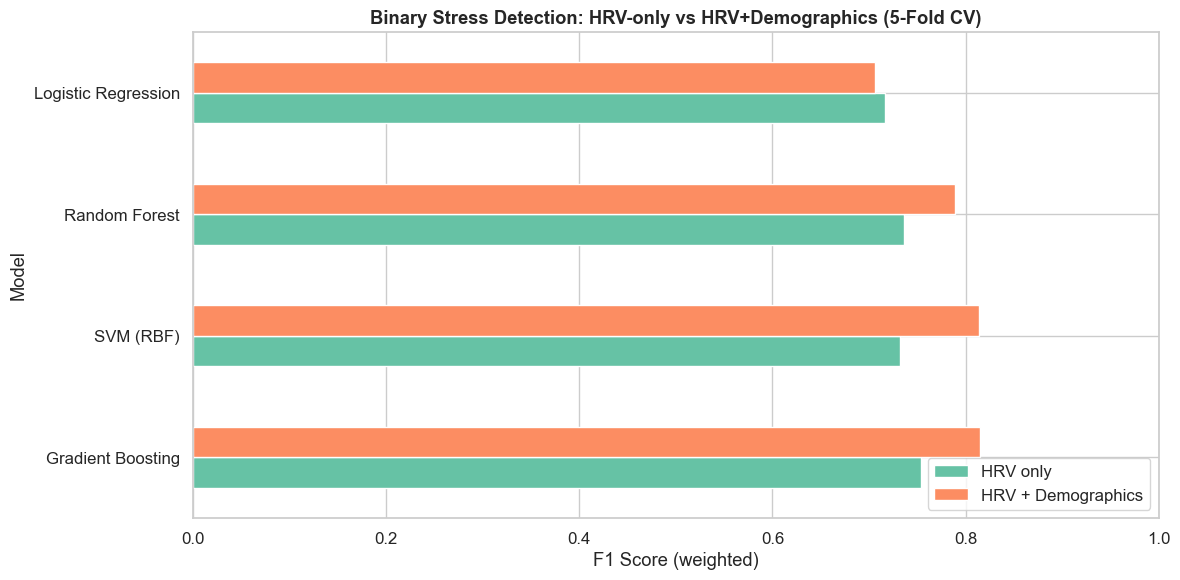

In [4]:
# Visualize HRV-only vs HRV+Demographics comparison
fig, ax = plt.subplots(figsize=(12, 6))

pivot = results_df.pivot(index='Model', columns='Features', values='F1').reindex(
    all_results['Model'].values
)
pivot[['hrv', 'all']].plot.barh(ax=ax, color=['#66c2a5', '#fc8d62'])
ax.set_xlabel('F1 Score (weighted)')
ax.set_title('Binary Stress Detection: HRV-only vs HRV+Demographics (5-Fold CV)', fontweight='bold')
ax.legend(['HRV only', 'HRV + Demographics'], loc='lower right')
ax.set_xlim(0, 1)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Leave-One-Subject-Out Cross-Validation

Most realistic evaluation: train on all subjects except one, predict on the held-out.
Uses **all features** (HRV + demographics).

In [5]:
logo = LeaveOneGroupOut()
loso_results = []

# Use all features (HRV + demographics) for LOSO
X = X_all

print(f'Running LOSO CV with all models (HRV + Demographics)...\n')
print(f'{"Model":<25} {"LOSO Acc":>10} {"LOSO F1":>10}')
print('-' * 47)

for name, model in model_defs.items():
    pipe = Pipeline([('scaler', StandardScaler()), ('clf', model)])
    y_pred = cross_val_predict(pipe, X, y_binary, cv=logo, groups=groups)
    acc = accuracy_score(y_binary, y_pred)
    f1  = f1_score(y_binary, y_pred, average='weighted')
    loso_results.append({'Model': name, 'LOSO_Accuracy': acc, 'LOSO_F1': f1})
    print(f'{name:<25} {acc:>10.4f} {f1:>10.4f}')

loso_df = pd.DataFrame(loso_results).sort_values('LOSO_F1', ascending=False)
final_best = loso_df.iloc[0]['Model']
print(f'\nBest model (LOSO F1): {final_best} — F1={loso_df.iloc[0]["LOSO_F1"]:.4f}')

Running LOSO CV with all models (HRV + Demographics)...

Model                       LOSO Acc    LOSO F1
-----------------------------------------------
Logistic Regression           0.6720     0.6647
Random Forest                 0.7268     0.6893
Gradient Boosting             0.7164     0.6955
SVM (RBF)                     0.7174     0.7078

Best model (LOSO F1): SVM (RBF) — F1=0.7078


## 4. Detailed Evaluation of Best Model

In [6]:
binary_labels = ['Not Stressed', 'Stressed']

best_clf = model_defs[final_best]
pipe_best = Pipeline([('scaler', StandardScaler()), ('clf', best_clf)])

y_pred_loso = cross_val_predict(pipe_best, X, y_binary, cv=logo, groups=groups)

print(f'=== {final_best} — LOSO Binary Classification Report ===\n')
print(classification_report(y_binary, y_pred_loso, target_names=binary_labels, digits=3))

# Also get LOSO probability predictions for stress level calibration
y_proba_loso = cross_val_predict(pipe_best, X, y_binary, cv=logo, groups=groups, method='predict_proba')
stress_proba = y_proba_loso[:, 1]

roc = roc_auc_score(y_binary, stress_proba)
brier = brier_score_loss(y_binary, stress_proba)
print(f'ROC AUC:     {roc:.4f}')
print(f'Brier Score: {brier:.4f} (lower=better calibrated)')

=== SVM (RBF) — LOSO Binary Classification Report ===

              precision    recall  f1-score   support

Not Stressed      0.796     0.841     0.818       799
    Stressed      0.407     0.336     0.368       259

    accuracy                          0.717      1058
   macro avg      0.601     0.588     0.593      1058
weighted avg      0.701     0.717     0.708      1058

ROC AUC:     0.6823
Brier Score: 0.1876 (lower=better calibrated)


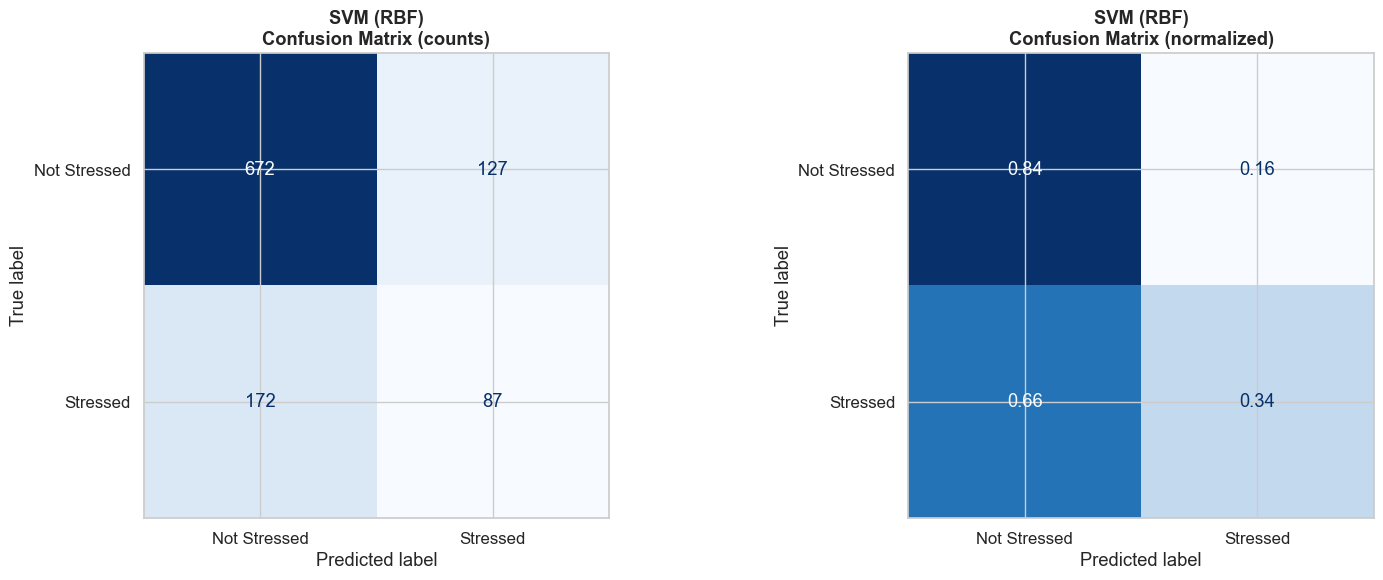

In [7]:
# Confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cm = confusion_matrix(y_binary, y_pred_loso)
disp1 = ConfusionMatrixDisplay(cm, display_labels=binary_labels)
disp1.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title(f'{final_best}\nConfusion Matrix (counts)', fontweight='bold')

cm_norm = confusion_matrix(y_binary, y_pred_loso, normalize='true')
disp2 = ConfusionMatrixDisplay(cm_norm, display_labels=binary_labels)
disp2.plot(ax=axes[1], cmap='Blues', colorbar=False, values_format='.2f')
axes[1].set_title(f'{final_best}\nConfusion Matrix (normalized)', fontweight='bold')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

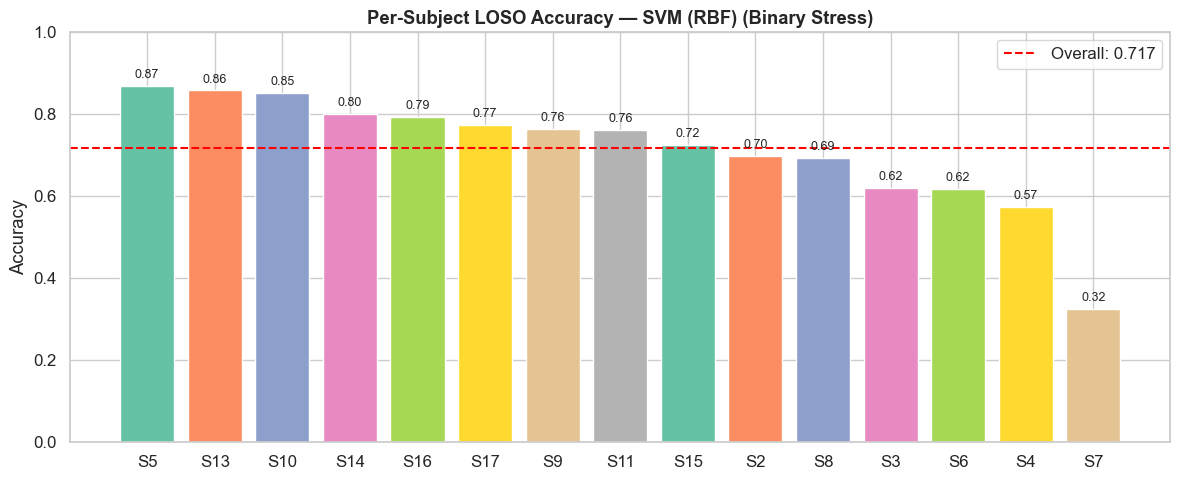

Subject  Accuracy  Samples
     S5  0.868421       38
    S13  0.857143       70
    S10  0.851064       94
    S14  0.800000       95
    S16  0.793103       87
    S17  0.773585       53
     S9  0.762500       80
    S11  0.761905       84
    S15  0.725000       80
     S2  0.696970       66
     S8  0.692308       52
     S3  0.620000       50
     S6  0.616667       60
     S4  0.573333       75
     S7  0.324324       74


In [8]:
# Per-subject accuracy
subj_acc = []
for subj in df['subject'].unique():
    mask = groups == subj
    acc = accuracy_score(y_binary[mask], y_pred_loso[mask])
    subj_acc.append({'Subject': subj, 'Accuracy': acc, 'Samples': mask.sum()})

subj_df = pd.DataFrame(subj_acc).sort_values('Accuracy', ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(subj_df['Subject'], subj_df['Accuracy'],
              color=sns.color_palette('Set2', len(subj_df)))
overall = accuracy_score(y_binary, y_pred_loso)
ax.axhline(y=overall, color='red', linestyle='--', label=f'Overall: {overall:.3f}')
ax.set_ylabel('Accuracy')
ax.set_title(f'Per-Subject LOSO Accuracy — {final_best} (Binary Stress)', fontweight='bold')
ax.legend()
ax.set_ylim(0, 1)
for bar, val in zip(bars, subj_df['Accuracy']):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.02, f'{val:.2f}',
            ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('per_subject_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()
print(subj_df.to_string(index=False))

## 5. Feature Importance (HRV + Demographics)

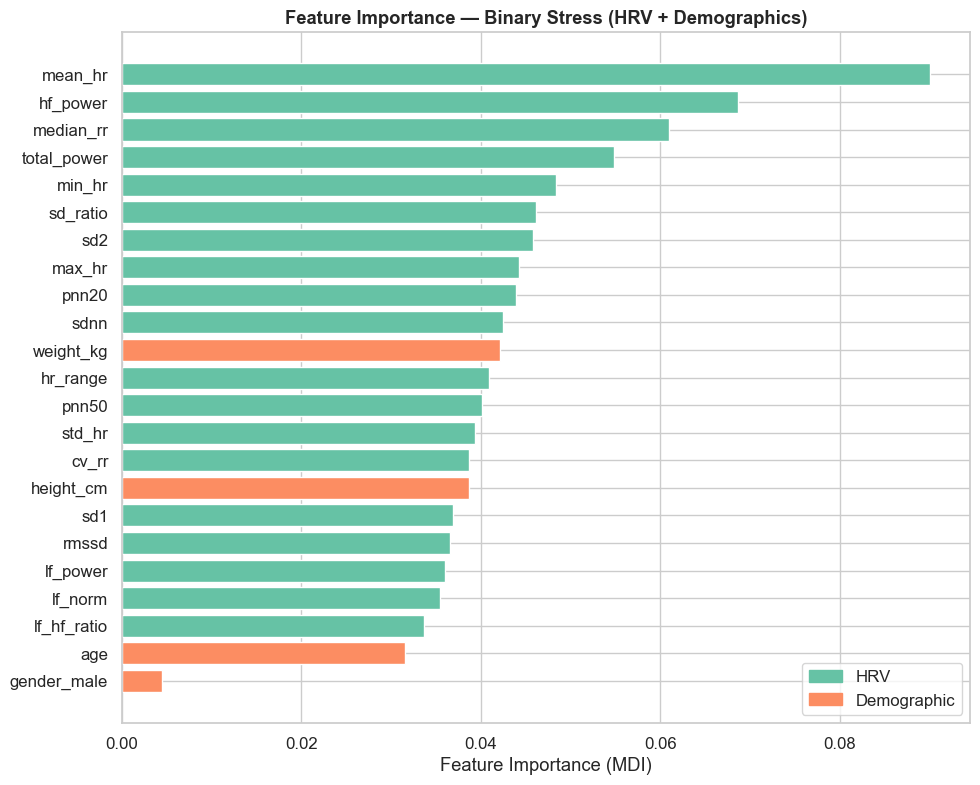


Top features:
  mean_hr        : 0.0900 (HRV)
  hf_power       : 0.0687 (HRV)
  median_rr      : 0.0609 (HRV)
  total_power    : 0.0548 (HRV)
  min_hr         : 0.0484 (HRV)
  sd_ratio       : 0.0461 (HRV)
  sd2            : 0.0458 (HRV)
  max_hr         : 0.0442 (HRV)
  pnn20          : 0.0439 (HRV)
  sdnn           : 0.0425 (HRV)
  weight_kg      : 0.0421 (Demographic)
  hr_range       : 0.0409 (HRV)
  pnn50          : 0.0401 (HRV)
  std_hr         : 0.0394 (HRV)
  cv_rr          : 0.0387 (HRV)
  height_cm      : 0.0386 (Demographic)
  sd1            : 0.0369 (HRV)
  rmssd          : 0.0366 (HRV)
  lf_power       : 0.0360 (HRV)
  lf_norm        : 0.0355 (HRV)
  lf_hf_ratio    : 0.0336 (HRV)
  age            : 0.0316 (Demographic)
  gender_male    : 0.0044 (Demographic)


In [9]:
# Train Random Forest on ALL data to get feature importances
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

rf_imp = RandomForestClassifier(
    n_estimators=300, max_depth=None, min_samples_split=5,
    min_samples_leaf=2, random_state=42, n_jobs=-1
)
rf_imp.fit(X_scaled, y_binary)

importances = rf_imp.feature_importances_
imp_df = pd.DataFrame({
    'Feature': FEATURE_COLS,
    'Importance': importances,
    'Type': ['Demographic' if c in DEMO_COLS else 'HRV' for c in FEATURE_COLS]
}).sort_values('Importance', ascending=True)

colors = ['#fc8d62' if t == 'Demographic' else '#66c2a5' for t in imp_df['Type']]

fig, ax = plt.subplots(figsize=(10, max(6, len(FEATURE_COLS) * 0.35)))
ax.barh(imp_df['Feature'], imp_df['Importance'], color=colors)
ax.set_xlabel('Feature Importance (MDI)')
ax.set_title('Feature Importance — Binary Stress (HRV + Demographics)', fontweight='bold')

# Legend
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='#66c2a5', label='HRV'), Patch(color='#fc8d62', label='Demographic')],
          loc='lower right')

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop features:')
for _, row in imp_df.sort_values('Importance', ascending=False).iterrows():
    print(f'  {row["Feature"]:15s}: {row["Importance"]:.4f} ({row["Type"]})')

## 6. Stress Level Distribution (LOSO probabilities)

Visualize the predicted stress level (%) distribution across actual conditions.

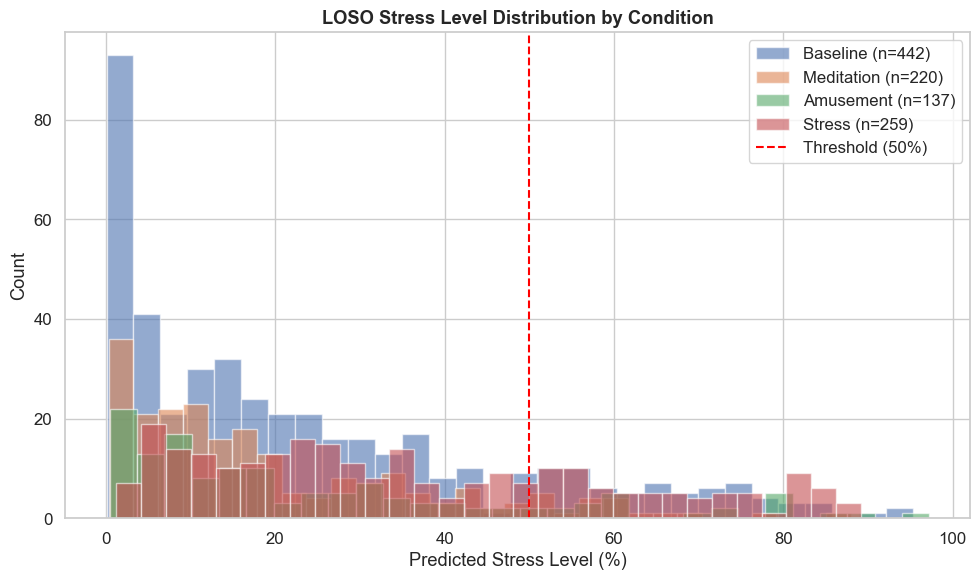


Mean stress level (%) per condition:
  Baseline    : 23.6% ± 22.7%
  Stress      : 36.0% ± 23.8%
  Amusement   : 24.3% ± 23.5%
  Meditation  : 19.2% ± 17.7%


In [10]:
# Show predicted stress % distribution per original condition
df['stress_pct_loso'] = stress_proba * 100

fig, ax = plt.subplots(figsize=(10, 6))
for cond in ['Baseline', 'Meditation', 'Amusement', 'Stress']:
    subset = df[df['label_name'] == cond]['stress_pct_loso']
    ax.hist(subset, bins=30, alpha=0.6, label=f'{cond} (n={len(subset)})')

ax.axvline(x=50, color='red', linestyle='--', linewidth=1.5, label='Threshold (50%)')
ax.set_xlabel('Predicted Stress Level (%)')
ax.set_ylabel('Count')
ax.set_title('LOSO Stress Level Distribution by Condition', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('stress_level_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Stats per condition
print('\nMean stress level (%) per condition:')
for cond in ['Baseline', 'Stress', 'Amusement', 'Meditation']:
    vals = df[df['label_name'] == cond]['stress_pct_loso']
    print(f'  {cond:12s}: {vals.mean():.1f}% ± {vals.std():.1f}%')

df.drop(columns=['stress_pct_loso'], inplace=True)

## 7. Train Final Model & Save

Train on ALL data and save:
- **Binary stress model** — outputs **stress level %** via `predict_proba`
- **Scaler**, **feature list**, **demographic defaults** for inference
- Demographics are optional: when missing at inference, medians from training data are used

In [11]:
# Final binary stress model (HRV + demographics)
final_model = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', model_defs[final_best])
])
final_model.fit(X, y_binary)

# Save all artifacts
artifacts = {
    'model': final_model,
    'feature_columns': FEATURE_COLS,          # ordered feature list (HRV + demographics)
    'hrv_columns': HRV_ONLY_COLS,             # HRV-only features
    'demo_columns': DEMO_COLS,                # demographic features
    'demo_defaults': demo_defaults,           # median values for imputation
    'binary_labels': {0: 'Not Stressed', 1: 'Stressed'},
    'training_info': {
        'n_samples': len(X),
        'n_subjects': df['subject'].nunique(),
        'best_model': final_best,
        'window_sec': 60,
        'step_sec': 30,
        'loso_f1': loso_df.iloc[0]['LOSO_F1'],
        'loso_accuracy': loso_df.iloc[0]['LOSO_Accuracy'],
    }
}

all_path = MODELS_DIR / 'all_artifacts.joblib'
joblib.dump(artifacts, all_path)

print(f'✅ Saved to {all_path} ({all_path.stat().st_size/1024:.1f} KB)')
print(f'   Model: {final_best}')
print(f'   Features: {len(FEATURE_COLS)} ({len(HRV_ONLY_COLS)} HRV + {len(DEMO_COLS)} demographic)')
print(f'   Demographic defaults: {demo_defaults}')

✅ Saved to models/all_artifacts.joblib (100.2 KB)
   Model: SVM (RBF)
   Features: 23 (19 HRV + 4 demographic)
   Demographic defaults: {'age': 27.0, 'gender_male': 1.0, 'height_cm': 178.0, 'weight_kg': 75.0}


## 8. Inference Demo — Stress Level %

Simulate the API: receive HRV features + optional demographics → predict stress level 0–100%.
When demographics are missing, dataset medians are used automatically.

In [12]:
import json

loaded = joblib.load(MODELS_DIR / 'all_artifacts.joblib')
model     = loaded['model']
feat_cols = loaded['feature_columns']
defaults  = loaded['demo_defaults']

def predict_stress(hrv_features: dict, demographics: dict = None) -> dict:
    """
    Predict stress level from HRV features + optional demographics.
    Returns stress_level_pct (0-100).
    """
    # Start with demographic defaults
    features = dict(defaults)
    # Override with actual demographics if provided
    if demographics:
        for k, v in demographics.items():
            if v is not None and k in defaults:
                features[k] = float(v)
    # Add HRV features
    features.update(hrv_features)
    
    X_new = np.array([[features[c] for c in feat_cols]])
    proba = model.predict_proba(X_new)[0]
    stress_pct = round(float(proba[1]) * 100, 1)
    
    return {
        'stress_level_pct': stress_pct,
        'is_stressed': bool(stress_pct >= 50),
    }

# Use real samples from the dataset for realistic demo values
HRV_COLS = loaded['hrv_columns']

stress_sample = df[df['label_name'] == 'Stress'].iloc[0]
relaxed_sample = df[df['label_name'] == 'Baseline'].iloc[0]

hrv_stressed = {c: float(stress_sample[c]) for c in HRV_COLS}
hrv_relaxed  = {c: float(relaxed_sample[c]) for c in HRV_COLS}

print('── Without demographics (uses dataset medians) ──')
for label, hrv in [('STRESSED', hrv_stressed), ('RELAXED', hrv_relaxed)]:
    result = predict_stress(hrv)
    print(f'  {label}: {json.dumps(result)}')

print('\n── With demographics ──')
demo = {'age': 25, 'gender_male': 1, 'height_cm': 180, 'weight_kg': 75}
for label, hrv in [('STRESSED', hrv_stressed), ('RELAXED', hrv_relaxed)]:
    result = predict_stress(hrv, demographics=demo)
    print(f'  {label}: {json.dumps(result)}')

print('\n── With partial demographics (only age) ──')
demo_partial = {'age': 30}
for label, hrv in [('STRESSED', hrv_stressed), ('RELAXED', hrv_relaxed)]:
    result = predict_stress(hrv, demographics=demo_partial)
    print(f'  {label}: {json.dumps(result)}')

── Without demographics (uses dataset medians) ──
  STRESSED: {"stress_level_pct": 44.8, "is_stressed": false}
  RELAXED: {"stress_level_pct": 0.6, "is_stressed": false}

── With demographics ──
  STRESSED: {"stress_level_pct": 18.1, "is_stressed": false}
  RELAXED: {"stress_level_pct": 0.4, "is_stressed": false}

── With partial demographics (only age) ──
  STRESSED: {"stress_level_pct": 58.7, "is_stressed": true}
  RELAXED: {"stress_level_pct": 1.4, "is_stressed": false}


## Summary

| What | Details |
|------|--------|
| Dataset | WESAD — 15 subjects, 4 conditions |
| HRV Features | 19 time-domain + frequency-domain + nonlinear (camera+flash only) |
| Demographics | age, gender_male, height_cm, weight_kg — **optional** (imputed with medians) |
| Total Features | 23 (19 HRV + 4 demographic) |
| Windows | 60s window, 30s step |
| Task | Binary: Stress vs Not Stressed |
| Output | **Stress level 0–100%** via `predict_proba` |
| Saved to | `models/all_artifacts.joblib` |

**Stress Level %:** The model uses `predict_proba` to output a continuous
stress confidence from 0% (definitely not stressed) to 100% (definitely stressed).

**Demographics are optional:** When the user hasn't provided demographics
(age, gender, height, weight), the API uses dataset medians for imputation.
The model still works well without demographics; they just add a small improvement.